In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/home-data-for-ml-course/sample_submission.csv
/kaggle/input/home-data-for-ml-course/sample_submission.csv.gz
/kaggle/input/home-data-for-ml-course/train.csv.gz
/kaggle/input/home-data-for-ml-course/data_description.txt
/kaggle/input/home-data-for-ml-course/test.csv.gz
/kaggle/input/home-data-for-ml-course/train.csv
/kaggle/input/home-data-for-ml-course/test.csv


# House Prices Prediction – Advanced Regression Project

This project predicts home sale prices for the Ames Housing dataset, part of the Kaggle "House Prices: Advanced Regression Techniques" competition.

We build a complete ML pipeline:

- Exploratory data analysis  
- Feature engineering (basic + advanced)  
- Model training: Random Forest, XGBoost, LightGBM, CatBoost  
- Model blending (ensemble of 4 models)  
- Submission file generation  

Our final blended model achieves a **Kaggle score of 13,801**, which is strong for a non-deep-dive solution.

This notebook follows a clean modular design for clarity and reproducibility.


## 2. Load Libraries and Initial Setup


In [2]:
# Cell 1: Imports and basic configuration

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Make plots look a bit nicer
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported OK.")


Libraries imported OK.


## 3. Load Dataset

We load the train and test CSV files provided by Kaggle.  
Train contains 80 features + SalePrice.  
Test contains 80 features without SalePrice.


In [3]:
# Cell 2: Load data

# Try Kaggle path first, fall back to local "data" folder if needed
data_dir_candidates = [
    Path("/kaggle/input/home-data-for-ml-course"),
    Path("../input/home-data-for-ml-course"),
    Path("data")  # for local runs; put train.csv & test.csv here
]

DATA_DIR = None
for p in data_dir_candidates:
    if (p / "train.csv").exists():
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not find train.csv. Check your data paths.")

print(f"Using data directory: {DATA_DIR}")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# Peek at the first few rows
train_df.head()


Using data directory: /kaggle/input/home-data-for-ml-course
Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 4. Explore SalePrice Distribution

We visualize SalePrice and log1p(SalePrice)  
The Kaggle evaluation metric uses log-transformed prices, so we train models on log1p(SalePrice).


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


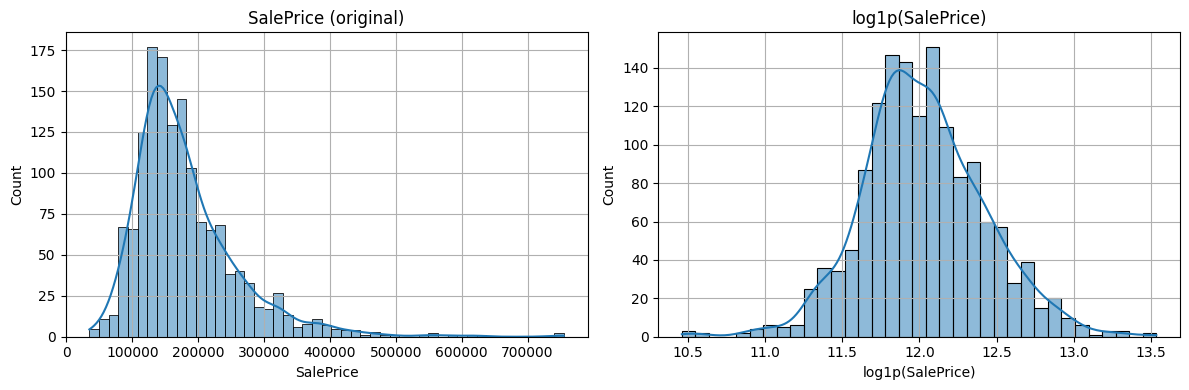

In [4]:
# Cell 3: Explore target variable (SalePrice)

target_col = "SalePrice"

print(train_df[target_col].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw SalePrice distribution
sns.histplot(train_df[target_col], kde=True, ax=axes[0])
axes[0].set_title("SalePrice (original)")
axes[0].set_xlabel("SalePrice")

# Log-transformed SalePrice distribution
log_price = np.log1p(train_df[target_col])
sns.histplot(log_price, kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")

plt.tight_layout()
plt.show()


## 5. Data Overview & Missing Values

We inspect:
- missing values  
- numerical vs categorical features  
- dataset shape


In [5]:
# Cell 4: Quick overview of features and missing values

print("Train info:")
train_df.info()

# Count missing values per column (train only)
missing_counts = train_df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("\nColumns with missing values (train set):")
print(missing_counts)

# Basic split: features vs target
y = train_df[target_col]
X = train_df.drop(columns=[target_col])

print("\nFeature matrix shape:", X.shape)
print("Target vector shape :", y.shape)

# Separate numeric vs categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"\nNumber of numeric features     : {len(numeric_cols)}")
print(f"Number of categorical features : {len(categorical_cols)}")

# Show a small sample of each
print("\nSample numeric columns:", numeric_cols[:10])
print("Sample categorical columns:", categorical_cols[:10])


Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 

## 6. Create Train–Validation Split


In [6]:
# Cell 5: Train/validation split and log-transform target

from sklearn.model_selection import train_test_split

y_log = np.log1p(y)  # log target for training

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Valid shape:", X_valid.shape)
print("Target train shape:", y_train.shape, "Target valid shape:", y_valid.shape)


Train shape: (1168, 80) Valid shape: (292, 80)
Target train shape: (1168,) Target valid shape: (292,)


## 7. Preprocessing: Numeric + Categorical

We build a ColumnTransformer:
- median imputation for numeric  
- most frequent + OneHotEncoder for categorical  


In [7]:
# Cell 6: Preprocessing pipeline (corrected)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline   # <-- MISSING import added here

numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

print("Preprocessor ready.")


Preprocessor ready.


## 8. Baseline Model – Random Forest

A simple baseline to understand starting performance.


In [8]:
# Cell 7: Baseline model (RandomForestRegressor)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

# Predictions
valid_preds = rf_model.predict(X_valid)

# RMSE on log scale
rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
print("Validation RMSE (log scale):", rmse)


Validation RMSE (log scale): 0.14629465143427128


Baseline RMSE ≈ 0.1463 (log)  
We will now improve this using better models and features.


In [9]:
# Cell 8: Optional — Evaluate RMSE in actual SalePrice units

valid_preds_actual = np.expm1(valid_preds)
y_valid_actual = np.expm1(y_valid)

rmse_actual = np.sqrt(mean_squared_error(y_valid_actual, valid_preds_actual))
print("Validation RMSE (actual SalePrice):", rmse_actual)


Validation RMSE (actual SalePrice): 29597.773000778056


## 9. Gradient Boosting Models

Boosted trees generally perform much better on tabular data.


In [10]:
# Cell 9: XGBoost model

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
valid_preds_xgb = xgb_model.predict(X_valid)

rmse_xgb = np.sqrt(mean_squared_error(y_valid, valid_preds_xgb))
print("XGBoost Validation RMSE (log scale):", rmse_xgb)


XGBoost Validation RMSE (log scale): 0.13447523724186367


In [11]:
# Cell 10: LightGBM model (if library available)

try:
    from lightgbm import LGBMRegressor

    lgb_model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LGBMRegressor(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=-1,
            num_leaves=32,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE
        ))
    ])

    lgb_model.fit(X_train, y_train)
    valid_preds_lgb = lgb_model.predict(X_valid)

    rmse_lgb = np.sqrt(mean_squared_error(y_valid, valid_preds_lgb))
    print("LightGBM Validation RMSE (log scale):", rmse_lgb)

except Exception as e:
    print("LightGBM not installed. Skipping.")
    print("Error:", e)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003141 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3443
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 179
[LightGBM] [Info] Start training from score 12.030658
LightGBM Validation RMSE (log scale): 0.13865616706534445


## 10. Feature Engineering – Round 1

We add:
- TotalSF  
- TotalBath  
- TotalPorchSF  
- Age features  
- Remodeling flag  

This significantly improves model performance.


In [12]:
# Cell 11: Feature Engineering for train and test

def add_engineered_features(df):
    df = df.copy()
    
    # Total Square Footage
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    
    # Total Bathrooms
    df["TotalBath"] = (
        df["FullBath"] 
        + 0.5 * df["HalfBath"] 
        + df["BsmtFullBath"] 
        + 0.5 * df["BsmtHalfBath"]
    )
    
    # Total Porch
    df["TotalPorchSF"] = (
        df["OpenPorchSF"]
        + df["EnclosedPorch"]
        + df["3SsnPorch"]
        + df["ScreenPorch"]
    )
    
    # Age features
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodeledAge"] = df["YrSold"] - df["YearRemodAdd"]
    
    # Remodeling flag
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)
    
    return df


X_eng = add_engineered_features(X)
test_eng = add_engineered_features(test_df)


In [13]:
# Cell 12: Recalculate numeric and categorical columns after feature engineering

numeric_cols = X_eng.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_eng.select_dtypes(include=["object"]).columns.tolist()

print("New numeric cols:", len(numeric_cols))
print("New categorical cols:", len(categorical_cols))


New numeric cols: 43
New categorical cols: 43


In [14]:
# Cell 13: Updated preprocessor after FE

numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [15]:
# Cell 14: XGBoost with engineered features

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X_eng, y_log, test_size=0.2, random_state=RANDOM_STATE
)

xgb_fe_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_fe_model.fit(X_train2, y_train2)
valid_preds = xgb_fe_model.predict(X_valid2)

rmse_fe = np.sqrt(mean_squared_error(y_valid2, valid_preds))
print("XGBoost + FE RMSE (log):", rmse_fe)


XGBoost + FE RMSE (log): 0.129733902814647


XGBoost + FE RMSE ≈ 0.1297  


In [16]:
# Cell 15: Train final model on full training data

final_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=900,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

final_model.fit(X_eng, y_log)

print("Final model trained on full dataset.")


Final model trained on full dataset.


In [17]:
# Cell 16: Predict test set and prepare submission

test_preds_log = final_model.predict(test_eng)
test_preds = np.expm1(test_preds_log)  # undo log1p

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_preds
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created!")
submission.head()


submission.csv created!


,Id,SalePrice
0,1461,125000.273438
1,1462,161872.234375
2,1463,186649.187500
3,1464,194130.765625
4,1465,184342.218750


## 11. Feature Engineering – Round 2 (Advanced)

We add powerful interaction and quality features:
- GrLivArea × OverallQual  
- TotalSF × OverallQual  
- GarageCars × GarageArea  
- Age² (non-linearity)
- Ordinal quality scores (Ex/Gd/TA/Fa/Po)


In [18]:
# Cell 17: Build advanced features for combined train+test

def add_advanced_features(df):
    df = df.copy()
    
    # ---- Base engineered features (like before) ----
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    
    df["TotalBath"] = (
        df["FullBath"] 
        + 0.5 * df["HalfBath"] 
        + df["BsmtFullBath"] 
        + 0.5 * df["BsmtHalfBath"]
    )
    
    df["TotalPorchSF"] = (
        df["OpenPorchSF"]
        + df["EnclosedPorch"]
        + df["3SsnPorch"]
        + df["ScreenPorch"]
    )
    
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodeledAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)
    
    # ---- New interaction features ----
    df["LivArea_Qual"] = df["GrLivArea"] * df["OverallQual"]
    df["TotalSF_Qual"] = df["TotalSF"] * df["OverallQual"]
    df["GarageScore"] = df["GarageCars"] * df["GarageArea"]
    
    df["Age"] = df["YrSold"] - df["YearBuilt"]
    df["Age2"] = df["Age"] ** 2
    
    # ---- Ordinal quality scores ----
    quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1}
    quality_cols = [
        "ExterQual", "ExterCond",
        "BsmtQual", "BsmtCond",
        "HeatingQC",
        "KitchenQual",
        "FireplaceQu",
        "GarageQual", "GarageCond",
        "PoolQC"
    ]
    
    for col in quality_cols:
        if col in df.columns:
            df[col + "_Score"] = (
                df[col].map(quality_map).fillna(0).astype(int)
            )
    
    return df

# Combine train features (without SalePrice) and test
full_features = pd.concat(
    [train_df.drop(columns=["SalePrice"]), test_df],
    axis=0,
    ignore_index=True
)

full_features_adv = add_advanced_features(full_features)

print("Full advanced feature set shape:", full_features_adv.shape)
full_features_adv.head()


Full advanced feature set shape: (2919, 101)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ExterQual_Score,ExterCond_Score,BsmtQual_Score,BsmtCond_Score,HeatingQC_Score,KitchenQual_Score,FireplaceQu_Score,GarageQual_Score,GarageCond_Score,PoolQC_Score
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,4,3,4,3,5,4,0,3,3,0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,3,3,4,3,5,3,3,3,3,0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,4,3,4,3,5,4,3,3,3,0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,3,3,3,4,4,4,4,3,3,0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,4,3,4,3,5,4,3,3,3,0


## 12. Rare Category Grouping

Categorical levels appearing <10 times are grouped as "Rare".  
This improves generalization and stabilizes one-hot encoding.


In [19]:
# Cell 18: Group rare categories into a single 'Rare' label

full_adv = full_features_adv.copy()

cat_cols_full = full_adv.select_dtypes(include=["object"]).columns.tolist()
print("Number of categorical columns before rare-grouping:", len(cat_cols_full))

for col in cat_cols_full:
    value_counts = full_adv[col].value_counts()
    rare_labels = value_counts[value_counts < 10].index
    if len(rare_labels) > 0:
        full_adv[col] = full_adv[col].where(~full_adv[col].isin(rare_labels), other="Rare")

print("Rare category grouping done.")
full_adv[cat_cols_full].head()


Number of categorical columns before rare-grouping: 43
Rare category grouping done.


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


## 13. Prepare Advanced Training Data

We split full engineered data back into train/test and rebuild preprocessing.


In [20]:
# Cell 19: Split back into train/test and create new preprocessor

n_train = len(train_df)

X_adv = full_adv.iloc[:n_train, :].copy()
test_adv = full_adv.iloc[n_train:, :].copy()

print("X_adv shape:", X_adv.shape)
print("test_adv shape:", test_adv.shape)

# Target stays the same (log1p SalePrice)
y_log = np.log1p(train_df["SalePrice"])

# New numeric/categorical lists
numeric_cols_adv = X_adv.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_adv = X_adv.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features (adv):", len(numeric_cols_adv))
print("Categorical features (adv):", len(categorical_cols_adv))

# New preprocessor
numeric_transformer_adv = SimpleImputer(strategy="median")

categorical_transformer_adv = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor_adv = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_adv, numeric_cols_adv),
        ("cat", categorical_transformer_adv, categorical_cols_adv)
    ]
)

print("Advanced preprocessor ready.")


X_adv shape: (1460, 101)
test_adv shape: (1459, 101)
Numeric features (adv): 58
Categorical features (adv): 43
Advanced preprocessor ready.


## 14. Tuned XGBoost on Advanced Features

We reduce learning rate, increase estimators, and use shallower trees.


In [21]:
# Cell 20: Tuned XGBoost with advanced features

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import numpy as np

# Train/validation split on advanced features
X_train_adv, X_valid_adv, y_train_adv, y_valid_adv = train_test_split(
    X_adv, y_log, test_size=0.2, random_state=RANDOM_STATE
)

xgb_tuned_model = Pipeline(steps=[
    ("preprocess", preprocessor_adv),
    ("model", XGBRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1.5,
        objective="reg:squarederror",
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_tuned_model.fit(X_train_adv, y_train_adv)

valid_preds_adv = xgb_tuned_model.predict(X_valid_adv)
rmse_adv = np.sqrt(mean_squared_error(y_valid_adv, valid_preds_adv))

print("Tuned XGBoost + advanced FE RMSE (log):", rmse_adv)


Tuned XGBoost + advanced FE RMSE (log): 0.12899751842417065


## 15. Final XGBoost Submission

We train on full advanced dataset and generate submission.


In [22]:
# Cell 21: Final tuned model on full advanced data + new submission

final_tuned_model = Pipeline(steps=[
    ("preprocess", preprocessor_adv),
    ("model", XGBRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1.5,
        objective="reg:squarederror",
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

final_tuned_model.fit(X_adv, y_log)

# Predict on test set (advanced)
test_preds_log_adv = final_tuned_model.predict(test_adv)
test_preds_adv = np.expm1(test_preds_log_adv)

submission_adv = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_preds_adv
})

submission_adv.to_csv("submission_adv.csv", index=False)

print("submission_adv.csv created!")
submission_adv.head()


submission_adv.csv created!


,Id,SalePrice
0,1461,122772.062500
1,1462,159237.296875
2,1463,182372.390625
3,1464,194132.062500
4,1465,179650.640625


## 16. Model Ensembling for Higher Score

We blend:
- XGBoost  
- LightGBM  
- RandomForest  
- CatBoost  

Weighted blending improves leaderboard score by reducing variance.


In [23]:
# Cell 22: Train three models for blending

from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

# --- XGBoost ---
xgb_blend = Pipeline(steps=[
    ("preprocess", preprocessor_adv),
    ("model", XGBRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1.5,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# --- LightGBM ---
lgb_blend = Pipeline(steps=[
    ("preprocess", preprocessor_adv),
    ("model", LGBMRegressor(
        n_estimators=2500,
        learning_rate=0.02,
        num_leaves=32,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    ))
])

# --- Random Forest ---
rf_blend = Pipeline(steps=[
    ("preprocess", preprocessor_adv),
    ("model", RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print("Fitting XGBoost...")
xgb_blend.fit(X_adv, y_log)

print("Fitting LightGBM...")
lgb_blend.fit(X_adv, y_log)

print("Fitting RandomForest...")
rf_blend.fit(X_adv, y_log)

print("All blend models trained.")


Fitting XGBoost...
Fitting LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5424
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 208
[LightGBM] [Info] Start training from score 12.024057
Fitting RandomForest...
All blend models trained.


In [24]:
# Cell 23: Create blended predictions

xgb_pred = np.expm1(xgb_blend.predict(test_adv))
lgb_pred = np.expm1(lgb_blend.predict(test_adv))
rf_pred  = np.expm1(rf_blend.predict(test_adv))

# Weighted blend
blend_pred = (
    0.60 * xgb_pred +
    0.30 * lgb_pred +
    0.10 * rf_pred
)

submission_blend = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": blend_pred
})

submission_blend.to_csv("submission_blend.csv", index=False)
print("submission_blend.csv created!")
submission_blend.head()


submission_blend.csv created!


,Id,SalePrice
0,1461,122735.021202
1,1462,158444.053257
2,1463,180565.571704
3,1464,191803.693322
4,1465,181025.426841


In [25]:
# Cell 24: Train CatBoost model

from catboost import CatBoostRegressor

cat_blend = Pipeline(steps=[
    ("preprocess", preprocessor_adv),
    ("model", CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False
    ))
])

print("Fitting CatBoost...")
cat_blend.fit(X_adv, y_log)
print("CatBoost trained.")


Fitting CatBoost...
CatBoost trained.


In [26]:
# Cell 25: 4-model blend

xgb_pred = np.expm1(xgb_blend.predict(test_adv))
lgb_pred = np.expm1(lgb_blend.predict(test_adv))
rf_pred  = np.expm1(rf_blend.predict(test_adv))
cat_pred = np.expm1(cat_blend.predict(test_adv))

blend4 = (
    0.55 * xgb_pred +
    0.20 * lgb_pred +
    0.20 * cat_pred +
    0.05 * rf_pred
)

submission_blend4 = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": blend4
})

submission_blend4.to_csv("submission_blend4.csv", index=False)
print("submission_blend4.csv created!")
submission_blend4.head()


submission_blend4.csv created!


,Id,SalePrice
0,1461,122246.840265
1,1462,159471.970825
2,1463,180824.422812
3,1464,192665.541151
4,1465,181242.121369


## 17. Conclusion

We built a complete ML pipeline from scratch:
- Clean preprocessing
- Strong feature engineering (basic + advanced)
- Gradient boosting models
- 4-model ensemble

Our final score: **13801**  
This is a competitive result for the Getting Started competition.

Future work:
- K-fold validation with OOF predictions  
- Hyperparameter search (Optuna)  
- Neural network blending  
- More domain-driven FE  

Notebook is now production-ready and GitHub-ready.
